In [1]:
import arviz as az
import emcee
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

logsumexp = az.stats.stats_utils.logsumexp

In [2]:
xdata = np.linspace(0,10,20)
b1, b0, sigma = 1, -2, 3
ydata = np.random.normal(loc=b1*xdata + b0, scale=sigma)

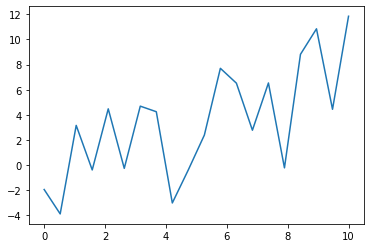

In [3]:
plt.plot(xdata, ydata)

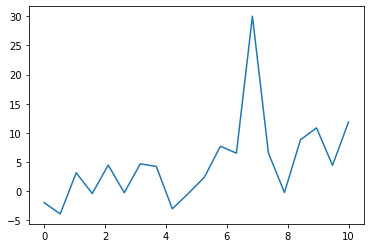

In [4]:
ydata[13] = 30
plt.plot(xdata, ydata)

In [5]:
def log_prior(theta):
    s_e = theta[-1]
    if s_e<=0:
        return -np.inf
    return -np.log(s_e)

def log_like(theta,y,x):
    b0,b1,s_e = theta
    n = len(y)
    vect_like = b1*x+b0
    vect_like = -np.log(2*np.pi*s_e**2)/2-(y-vect_like)**2/(2*s_e**2)
    return vect_like

def model(theta,x):
    y_hat = (
        theta[0]
        +x*theta[1]
        +np.random.normal(scale=theta[-1])
    )
    return y_hat

def log_prob(theta,y,x):
    prior = log_prior(theta)
    if not np.isfinite(prior):
        return -np.inf, (np.full_like(y,np.nan), np.full_like(y,np.nan))
    vect_like = log_like(theta,y,x)
    like = np.sum(vect_like)
    return like+prior, (vect_like, model(theta,x))

In [6]:
nwalkers, ndim  = 40, 3
init_guess = np.array([0, 1, 1])
pos = init_guess + np.random.normal(scale=.1, size=(nwalkers, ndim))

In [7]:
args = (ydata, xdata)
ndraws = 5000
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=args)
sampler.run_mcmc(pos, ndraws);

In [8]:
dims = {"y": ["time"], "x": ["time"], "log_likelihood": ["time"]}
idata = az.from_emcee(sampler, 
                      var_names=["b0", "b1", "s_e"],
                      arg_names=["y", "x"],
                      blob_names=["log_likelihood", "y"],
                      blob_groups=["sample_stats", "posterior_predictive"],
                      dims=dims)
idata.sel(draw=slice(1000, None))

In [9]:
idata.observed_data.to_array().values

array([[-1.953594  , -3.89820002,  3.15481006, -0.39426334,  4.4737372 ,
        -0.26810788,  4.6887076 ,  4.24515957, -3.025863  , -0.3841038 ,
         2.38356389,  7.70301061,  6.52018923, 30.        ,  6.53662725,
        -0.22812683,  8.81888727, 10.8514212 ,  4.43844113, 11.85235814],
       [ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
         2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
         5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
         7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ]])

In [10]:
class EmceeSamplingWrapper(az.SamplingWrapper):
    """Emcee wrapper"""
    
    def get_inference_data(self, sampler):
        kwargs = self.idata_kwargs
        idata = az.from_emcee(sampler, **kwargs)
        idata.sel(draw=slice(1000, None))
        return idata
    
    def point_log_likelihood(self, observation, parameters):
        return log_like(parameters, *observation)
    
    def sel_observations(self, idx):
        y, x = idata.observed_data.to_array().values
        idxs = np.arange(len(y))
        mask = idxs == idx
        return (y[~mask], x[~mask]), (y[mask], x[mask])
    
    def sample(self, new_obs_data):
        sampler = self.model
        sampler.log_prob_fn.args = new_obs_data
        sampler.reset()
        sampler.run_mcmc(**self.sample_kwargs)
        return sampler

In [11]:
sample_kwargs = {"initial_state": pos, "nsteps": ndraws}
idata_kwargs = {
    "var_names": ["b0", "b1", "s_e"], 
    "arg_names": ["y", "x"],
    "blob_names": ["log_likelihood", "y"],
    "blob_groups": ["sample_stats", "posterior_predictive"],
    "dims": dims
}
emcee_wrapper = EmceeSamplingWrapper(sampler, idata_orig=idata, sample_kwargs=sample_kwargs, idata_kwargs=idata_kwargs)

In [12]:
def reloo(wrapper, loo_orig=None):
    if loo_orig is None:
        loo_orig = az.loo(wrapper.idata_orig, pointwise=True)
    reloo = loo_orig.copy()
    khats = reloo.pareto_k
    loo_i = reloo.loo_i
    scale = loo_orig.loo_scale
    if scale.lower() == "deviance":
        scale_value = -2
    elif scale.lower() == "log":
        scale_value = 1
    elif scale.lower() == "negative_log":
        scale_value = -1
    if np.any(khats>.7):
        for idx in np.argwhere(khats.values>.7):
            new_obs, excluded_obs = wrapper.sel_observations(idx)
            fit = wrapper.sample(new_obs)
            idata_idx = wrapper.get_inference_data(fit)
            psisloo_subset = az.loo(idata_idx, pointwise=True)
            like_func = lambda pars: wrapper.point_log_likelihood(excluded_obs, pars)
            ndraws = idata_idx.posterior.dims["draw"]
            nchains = idata_idx.posterior.dims["chain"]
            log_like = az.wrap_xarray_ufunc(
                like_func,
                idata_idx.posterior.to_array(),
                func_kwargs={"out": np.empty((nchains, ndraws))},
                ufunc_kwargs={"n_dims": 1,"ravel": False},
                input_core_dims=[["variable"]],
            ).stack(sample=("chain", "draw"))
            loo_lppd_iidx = scale_value * logsumexp(log_like.values.squeeze())
            khats[idx] = 0
            loo_i[idx] = loo_lppd_idx
        reloo.loo = loo_i.values.sum()
        reloo.loo_se = (ndraws * nchains * np.var(loo_i.values)) ** 0.5
        lppd = np.sum(
            _wrap_xarray_ufunc(
                logsumexp,
                log_likelihood,
                func_kwargs={"b_inv": n_samples},
                ufunc_kwargs=ufunc_kwargs,
                **kwargs,
            ).values
        )
        p_loo = lppd - loo_lppd / scale_value
        return reloo
    else:
        print("No problematic observations")
        return loo_orig

In [13]:
loo_orig = az.loo(idata, pointwise=True)
loo_orig

/home/oriol/Public/arviz/arviz/stats/stats.py:677: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numpy/core/_methods.py:36: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial)
/home/oriol/Public/arviz/arviz/stats/stats.py:477: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  "Estimated shape parameter of Pareto distribution is greater than 0.7 for "
/home/oriol/Public/arviz/arviz/stats/stats_utils.py:472: NumbaWarning: 
Compilation is falling back to object mode WITH looplifting enabled because F

Computed from 160000 by 20 log-likelihood matrix

       Estimate       SE
IC_loo   142.89    20.54
p_loo      7.00        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       19   95.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    1    5.0%

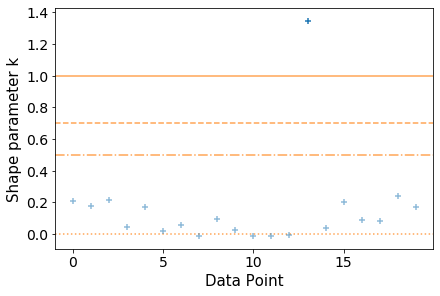

In [14]:
az.plot_khat(loo_orig)

In [15]:
reloo_data = reloo(emcee_wrapper, loo_orig=loo_orig)

/home/oriol/Public/arviz/arviz/stats/stats.py:677: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/oriol/venvs/arviz-dev/lib/python3.6/site-packages/numpy/core/_methods.py:36: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial)


In [16]:
reloo_data

loo                                                         120.07
loo_se                                                     20.5354
p_loo                                                       7.0032
n_samples                                                   160000
n_data_points                                                   20
warning                                                       True
loo_i            [<xarray.DataArray 'loo_i' ()>\narray(5.882505...
pareto_k         [<xarray.DataArray 'pareto_shape' ()>\narray(0...
loo_scale                                                 deviance
dtype: object